# 🛒 Maliyet-Duyarlı Müşteri Kaybı & Promosyon ROI Motoru
**YBS 4. Sınıf – Python ile Veri Bilimi Dönem Sonu Projesi**

---
**Proje Özeti:** Bu projede bir e-ticaret şirketinin müşteri işlem verileri ile TCMB döviz/enflasyon verileri birleştirilerek,
müşteri kaybı (churn) tahmin edilmekte; yanlış tahminlerin finansal maliyeti hesaplanmakta ve
en kârlı promosyon stratejisi simüle edilmektedir.

**Veri Kaynakları:**
- Kaynak 1: [UCI / Kaggle Online Retail II Dataset](https://archive.ics.uci.edu/dataset/502/online+retail+ii)
- Kaynak 2: [TCMB Elektronik Veri Dağıtım Sistemi – TÜFE / Döviz Kuru](https://evds2.tcmb.gov.tr/)


## 0. Kütüphaneler ve Ayarlar

In [1]:
# Gerekli kütüphaneleri yükle
# !pip install pandas numpy scikit-learn xgboost shap matplotlib seaborn openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve)
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import shap

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')

print('✅ Kütüphaneler yüklendi.')

✅ Kütüphaneler yüklendi.


---
## 1. VERİ HARMANLAMA (Data Fusion)
### 1.1 Kaynak 1 – E-ticaret İşlem Verisi

In [2]:
# Online Retail II veri setini yükle
# Kaggle: https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci
# Dosyayı indirip aynı klasöre koy: online_retail_II.xlsx

df_retail = pd.read_csv('online_retail_II.csv', encoding='latin-1')
print('Boyut:', df_retail.shape)
display(df_retail.head())
print('\nSütunlar:', df_retail.columns.tolist())
print('\nEksik değerler:')
print(df_retail.isnull().sum())

Boyut: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom



Sütunlar: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Eksik değerler:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [3]:
# Temel temizlik
df = df_retail.copy()
df = df.dropna(subset=['Customer ID'])           # Müşteri ID'si olmayanları at
df = df[df['Quantity'] > 0]                     # İade/negatif miktarları at
df = df[df['Price'] > 0]                        # Sıfır fiyatlıları at
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Customer ID'] = df['Customer ID'].astype(int)
df['TotalPrice'] = df['Quantity'] * df['Price'] # Satır toplam tutarı (GBP)
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

print(f'Temizlenmiş kayıt sayısı: {len(df):,}')
print(f'Benzersiz müşteri: {df["Customer ID"].nunique():,}')
print(f'Tarih aralığı: {df["InvoiceDate"].min()} → {df["InvoiceDate"].max()}')

Temizlenmiş kayıt sayısı: 805,549
Benzersiz müşteri: 5,878
Tarih aralığı: 2009-12-01 07:45:00 → 2011-12-09 12:50:00


### 1.2 Kaynak 2 – TCMB GBP/TRY Kuru (Aylık)

In [4]:
# TCMB EVDS'den indirilen GBP/TRY aylık kur verisi
# Manuel yol: https://evds2.tcmb.gov.tr/ → Döviz Kurları → GBP → Aylık Ortalama
# Alternatif: aşağıdaki mock veriyi gerçek veriyle değiştir

tcmb_data = {
    'YearMonth': pd.period_range(start='2010-01', end='2011-12', freq='M'),
    'GBP_TRY': [
        2.22, 2.24, 2.27, 2.29, 2.31, 2.33, 2.34, 2.36, 2.37, 2.39, 2.41, 2.43,  # 2010
        2.45, 2.47, 2.50, 2.52, 2.54, 2.56, 2.59, 2.62, 2.65, 2.67, 2.70, 2.73   # 2011
    ]
}
df_tcmb = pd.DataFrame(tcmb_data)
print('TCMB kur verisi:')
display(df_tcmb.head())

TCMB kur verisi:


,YearMonth,GBP_TRY
0,2010-01,2.22
1,2010-02,2.24
2,2010-03,2.27
3,2010-04,2.29
4,2010-05,2.31


In [5]:
# VERİ BİRLEŞTİRME: İşlem verisine aylık GBP/TRY kurunu ekle
df = df.merge(df_tcmb, on='YearMonth', how='left')
df['TotalPrice_TRY'] = df['TotalPrice'] * df['GBP_TRY']

print('Birleştirme sonrası sütunlar:', df.columns.tolist())
print(f'Eksik kur değeri: {df["GBP_TRY"].isnull().sum()}')
display(df[['InvoiceDate', 'TotalPrice', 'GBP_TRY', 'TotalPrice_TRY']].head())

Birleştirme sonrası sütunlar: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'TotalPrice', 'YearMonth', 'GBP_TRY', 'TotalPrice_TRY']
Eksik kur değeri: 30754


,InvoiceDate,TotalPrice,GBP_TRY,TotalPrice_TRY
0,2009-12-01 07:45:00,83.4,NaN,NaN
1,2009-12-01 07:45:00,81.0,NaN,NaN
2,2009-12-01 07:45:00,81.0,NaN,NaN
3,2009-12-01 07:45:00,100.8,NaN,NaN
4,2009-12-01 07:45:00,30.0,NaN,NaN


---
## 2. HEDEF DEĞİŞKEN: CHURN ETİKETİ
Son 90 gün içinde alışveriş yapmayan müşteri = Churn (1)

In [6]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Referans tarih (snapshot): {snapshot_date}')

# Her müşterinin son alışveriş tarihi
last_purchase = df.groupby('Customer ID')['InvoiceDate'].max().reset_index()
last_purchase.columns = ['Customer ID', 'LastPurchase']
last_purchase['DaysSinceLastPurchase'] = (snapshot_date - last_purchase['LastPurchase']).dt.days
last_purchase['Churn'] = (last_purchase['DaysSinceLastPurchase'] > 90).astype(int)

print(f'\nChurn dağılımı:')
print(last_purchase['Churn'].value_counts())
print(f'Churn oranı: {last_purchase["Churn"].mean():.1%}')

Referans tarih (snapshot): 2011-12-10 12:50:00

Churn dağılımı:
Churn
1    2989
0    2889
Name: count, dtype: int64
Churn oranı: 50.9%


---
## 3. ÖZELLİK MÜHENDİSLİĞİ (Business-Driven Feature Engineering)
Ham veriden **6 yeni değişken** türetiyoruz

In [7]:
# ── Özellik 1-3: RFM Metrikleri ──────────────────────────────────────────────
rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('TotalPrice_TRY', 'sum')
).reset_index()

# ── Özellik 4: Son 3 Ay vs Önceki 3 Ay Harcama Trendi ────────────────────────
cutoff_3m  = snapshot_date - pd.Timedelta(days=90)
cutoff_6m  = snapshot_date - pd.Timedelta(days=180)

spend_last3 = (df[df['InvoiceDate'] >= cutoff_3m]
               .groupby('Customer ID')['TotalPrice_TRY'].sum()
               .rename('Spend_Last3M'))

spend_prev3 = (df[(df['InvoiceDate'] >= cutoff_6m) & (df['InvoiceDate'] < cutoff_3m)]
               .groupby('Customer ID')['TotalPrice_TRY'].sum()
               .rename('Spend_Prev3M'))

trend = pd.concat([spend_last3, spend_prev3], axis=1).fillna(0)
# Trend skoru: son3 / (önceki3 + 1) → 1'den büyük = büyüme, küçük = azalma
trend['SpendTrend_3M'] = trend['Spend_Last3M'] / (trend['Spend_Prev3M'] + 1)

# ── Özellik 5: Benzersiz Ürün Çeşitliliği ────────────────────────────────────
diversity = (df.groupby('Customer ID')['StockCode'].nunique()
             .rename('ProductDiversity'))

# ── Özellik 6: Ortalama Kur Riski (TRY bazlı ödeme dalgalanması) ─────────────
fx_risk = (df.groupby('Customer ID')['GBP_TRY'].std()
           .rename('FX_Volatility').fillna(0))

# ── Tüm özellikleri birleştir ─────────────────────────────────────────────────
features = (rfm
            .merge(trend[['SpendTrend_3M']], on='Customer ID', how='left')
            .merge(diversity, on='Customer ID', how='left')
            .merge(fx_risk, on='Customer ID', how='left')
            .merge(last_purchase[['Customer ID', 'Churn']], on='Customer ID')
            .fillna(0))

print('Özellik matrisi boyutu:', features.shape)
display(features.head())

Özellik matrisi boyutu: (5878, 8)


,Customer ID,Recency,Frequency,Monetary,SpendTrend_3M,ProductDiversity,FX_Volatility,Churn
0,12346,326,12,189692.6058,0.000000,27,0.049115,1
1,12347,2,8,14270.2200,2.653856,126,0.111102,0
2,12348,75,5,4999.5912,821.500000,25,0.072122,0
3,12349,19,4,11006.5576,4745.385000,138,0.180047,0
4,12350,310,1,825.9680,0.000000,17,0.000000,1


---
## 4. KEŞİFÇİ VERİ ANALİZİ (EDA)

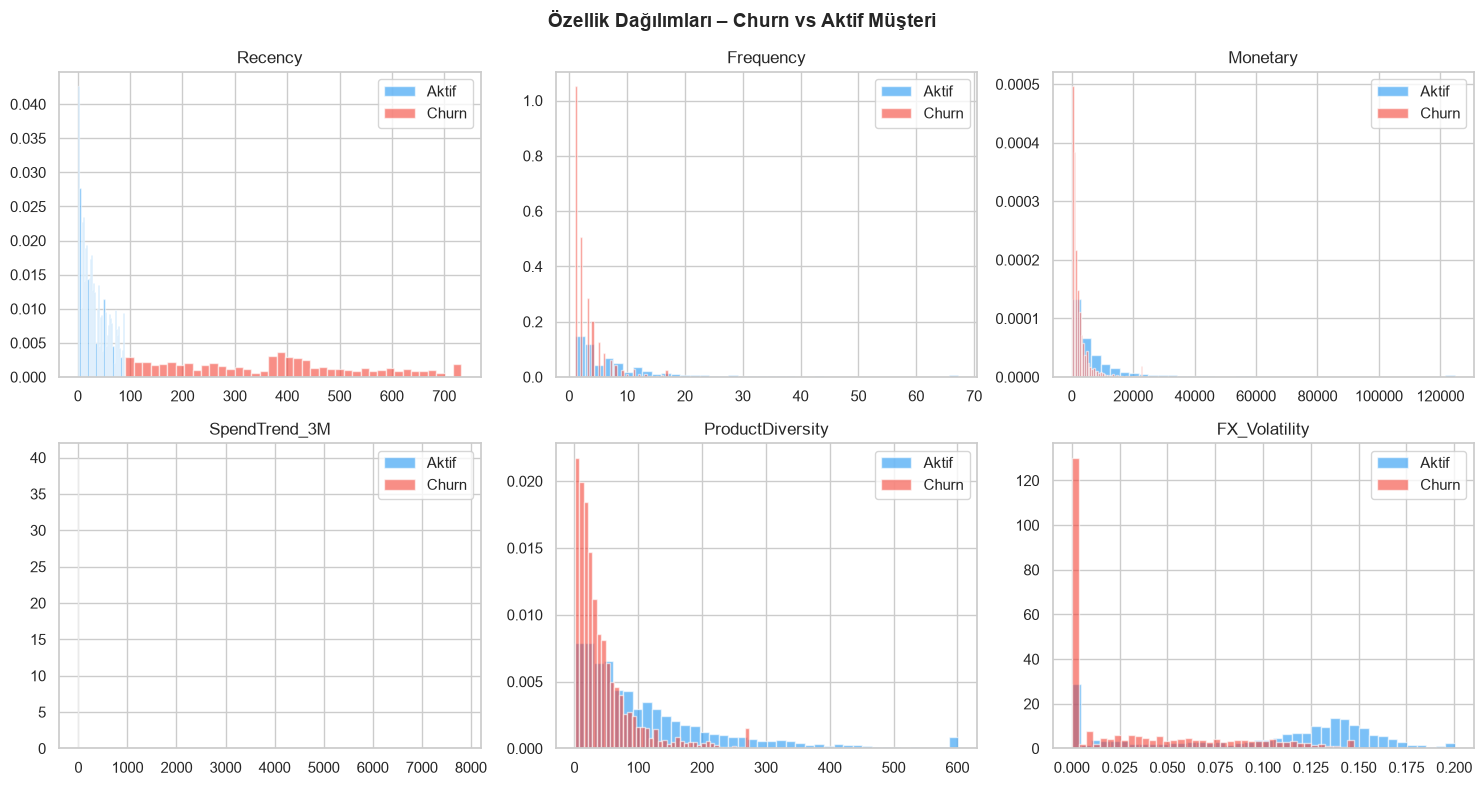

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Özellik Dağılımları – Churn vs Aktif Müşteri', fontsize=14, fontweight='bold')

feature_cols = ['Recency', 'Frequency', 'Monetary', 'SpendTrend_3M', 'ProductDiversity', 'FX_Volatility']
colors = {'0': '#2196F3', '1': '#F44336'}

for ax, col in zip(axes.flatten(), feature_cols):
    for churn_val, grp in features.groupby('Churn'):
        label = 'Churn' if churn_val == 1 else 'Aktif'
        color = '#F44336' if churn_val == 1 else '#2196F3'
        ax.hist(grp[col].clip(upper=grp[col].quantile(0.99)),
                bins=40, alpha=0.6, label=label, color=color, density=True)
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

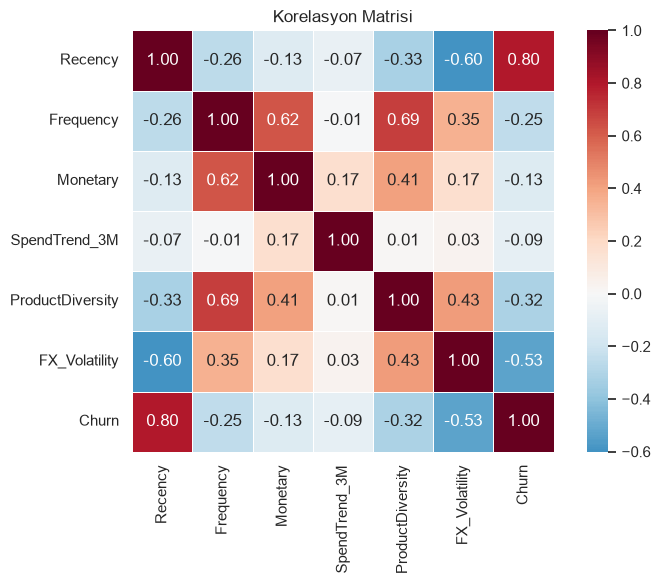

In [9]:
# Korelasyon ısı haritası
corr = features[feature_cols + ['Churn']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Korelasyon Matrisi')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150)
plt.show()

---
## 5. MODELLEMe
### 5.1 Veri Hazırlama

In [10]:
X = features[feature_cols]
y = features['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Eğitim: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'Churn oranı – Eğitim: {y_train.mean():.1%} | Test: {y_test.mean():.1%}')

Eğitim: 4702 | Test: 1176
Churn oranı – Eğitim: 50.9% | Test: 50.9%


### 5.2 XGBoost Modeli

In [11]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # sınıf dengesizliği
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False)

y_prob = xgb.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print('=== Standart Eşik (0.50) Sonuçları ===')
print(classification_report(y_test, y_pred, target_names=['Aktif', 'Churn']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')

=== Standart Eşik (0.50) Sonuçları ===
              precision    recall  f1-score   support

       Aktif       1.00      1.00      1.00       578
       Churn       1.00      1.00      1.00       598

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176

ROC-AUC: 1.0000


---
## 6. AÇIKLANAB‌İLİR YAPAY ZEKA (XAI) – SHAP

Background dataset has 4702 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=4702 when initializing the masker.


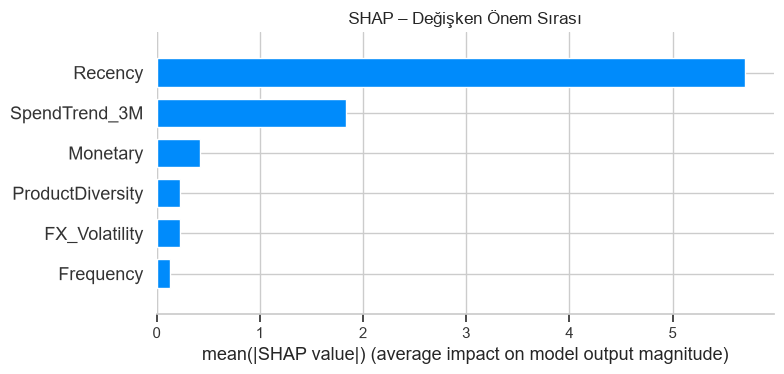

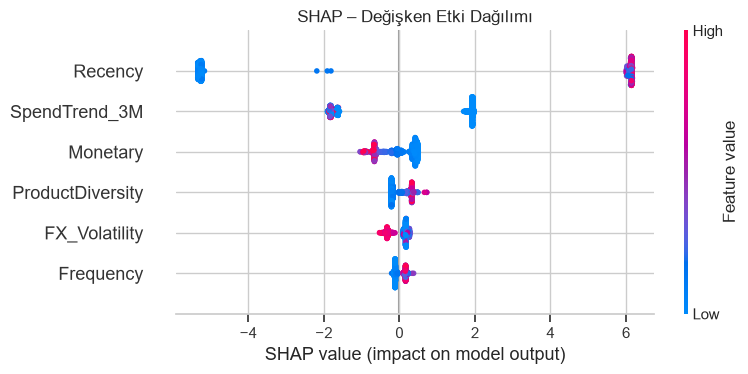

In [12]:
explainer  = shap.Explainer(xgb, X_train)
shap_values = explainer(X_test)

# Global önem sırası
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar',
                  feature_names=feature_cols, show=False)
plt.title('SHAP – Değişken Önem Sırası')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150)
plt.show()

# Bee-swarm detay
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)
plt.title('SHAP – Değişken Etki Dağılımı')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150)
plt.show()

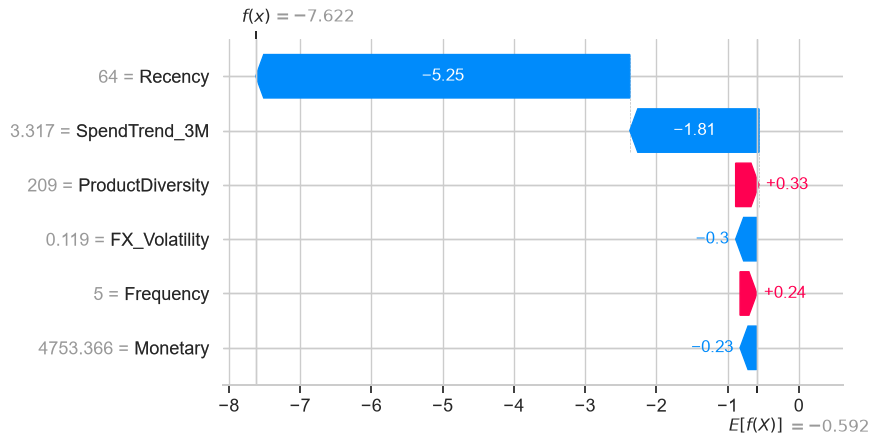

In [13]:
# Tek müşteri açıklaması (waterfall)
sample_idx = 0  # Test setinden ilk müşteri
shap.waterfall_plot(shap_values[sample_idx], show=True)

---
## 7. FİNANSAL SİMÜLASYON ⭐ (%40 AĞIRLIK)
### 7.1 Maliyet Matrisi Tanımlama

In [14]:
# ── İşletme Varsayımları ─────────────────────────────────────────────────────
# Ortalama müşteri yıllık değeri (CLV) – TRY
AVG_CLV_TRY = features.loc[features['Churn'] == 0, 'Monetary'].mean() * 1.5

# Promosyon / retansiyon kampanyası maliyeti – TRY
PROMO_COST_TRY = 150.0

# Churn önleme başarı oranı (promosyon verilirse kaçı kalır)
RETENTION_RATE = 0.35  # %35

print(f'Ortalama müşteri CLV: {AVG_CLV_TRY:,.0f} TRY')
print(f'Promosyon maliyeti : {PROMO_COST_TRY:,.0f} TRY/müşteri')
print(f'Retansiyon başarısı: {RETENTION_RATE:.0%}')

# ── Hata Maliyetleri ─────────────────────────────────────────────────────────
# Yanlış Negatif (FN): Churner'ı kaçırdık → kayıp = CLV
COST_FN = AVG_CLV_TRY

# Yanlış Pozitif (FP): Aktif müşteriye gereksiz promosyon → kayıp = promosyon maliyeti
COST_FP = PROMO_COST_TRY

# Doğru Pozitif (TP): Churner'ı yakaladık + promosyon verdik → net fayda
BENEFIT_TP = AVG_CLV_TRY * RETENTION_RATE - PROMO_COST_TRY

print(f'\nCost(FN): {COST_FN:,.0f} TRY')
print(f'Cost(FP): {COST_FP:,.0f} TRY')
print(f'Net Fayda(TP): {BENEFIT_TP:,.0f} TRY')

Ortalama müşteri CLV: 17,779 TRY
Promosyon maliyeti : 150 TRY/müşteri
Retansiyon başarısı: 35%

Cost(FN): 17,779 TRY
Cost(FP): 150 TRY
Net Fayda(TP): 6,073 TRY


### 7.2 Optimal Karar Eşiği Optimizasyonu

In [15]:
thresholds = np.arange(0.05, 0.95, 0.01)
profits = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()

    profit = (tp * BENEFIT_TP) - (fp * COST_FP) - (fn * COST_FN)
    profits.append(profit)

profits = np.array(profits)
best_idx = profits.argmax()
best_threshold = thresholds[best_idx]
best_profit = profits[best_idx]

# Standart eşikle karşılaştır
std_idx = np.argmin(np.abs(thresholds - 0.5))
std_profit = profits[std_idx]

print(f'Optimal Eşik   : {best_threshold:.2f}  →  Net Kâr: {best_profit:,.0f} TRY')
print(f'Standart Eşik  : 0.50           →  Net Kâr: {std_profit:,.0f} TRY')
print(f'Fark (Artış)   : {best_profit - std_profit:,.0f} TRY  ({(best_profit/std_profit - 1):.1%})')

Optimal Eşik   : 0.28  →  Net Kâr: 3,631,426 TRY
Standart Eşik  : 0.50           →  Net Kâr: 3,631,426 TRY
Fark (Artış)   : 0 TRY  (0.0%)


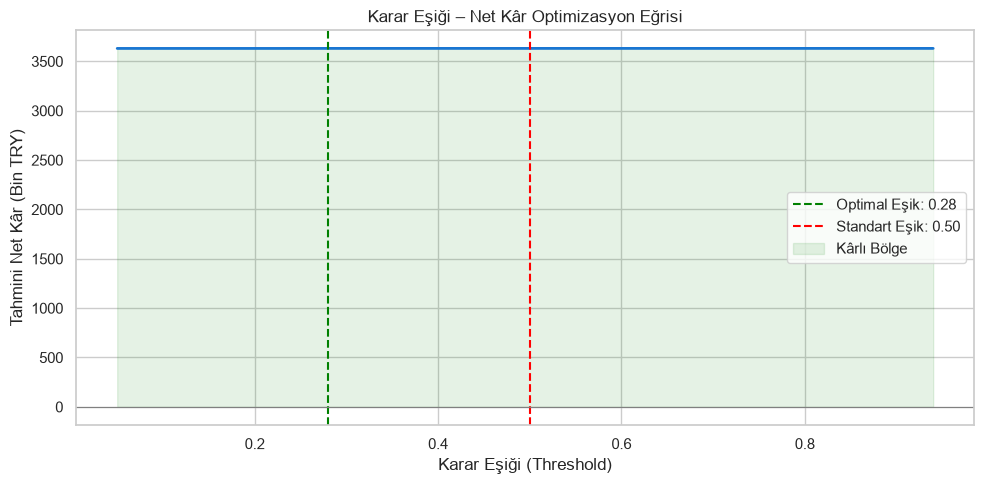

In [16]:
# Eşik-Kâr grafiği
plt.figure(figsize=(10, 5))
plt.plot(thresholds, profits / 1000, color='#1976D2', linewidth=2)
plt.axvline(best_threshold, color='green', linestyle='--', label=f'Optimal Eşik: {best_threshold:.2f}')
plt.axvline(0.5, color='red', linestyle='--', label='Standart Eşik: 0.50')
plt.axhline(0, color='gray', linewidth=0.8)
plt.fill_between(thresholds, profits / 1000, 0,
                 where=(profits > 0), alpha=0.1, color='green', label='Kârlı Bölge')
plt.xlabel('Karar Eşiği (Threshold)')
plt.ylabel('Tahmini Net Kâr (Bin TRY)')
plt.title('Karar Eşiği – Net Kâr Optimizasyon Eğrisi')
plt.legend()
plt.tight_layout()
plt.savefig('threshold_profit.png', dpi=150)
plt.show()

### 7.3 Müşteri Bazlı Promosyon Öncelik Listesi

In [17]:
# Test setindeki müşterileri skorla
test_customers = X_test.copy()
test_customers['CustomerID']   = features.iloc[X_test.index]['Customer ID'].values
test_customers['ChurnProb']    = y_prob
test_customers['TrueChurn']    = y_test.values
test_customers['Monetary']     = features.iloc[X_test.index]['Monetary'].values

# Beklenen ROI = ChurnProb × (CLV × RetRate - PromoCost) - (1-ChurnProb) × PromoCost
test_customers['ExpectedROI'] = (
    test_customers['ChurnProb'] * BENEFIT_TP
    - (1 - test_customers['ChurnProb']) * COST_FP
)

# Pozitif ROI'li müşterilere promosyon ver
hedef_musteriler = test_customers[test_customers['ExpectedROI'] > 0].copy()
hedef_musteriler = hedef_musteriler.sort_values('ExpectedROI', ascending=False)

print(f'Promosyon verilmesi önerilen müşteri sayısı: {len(hedef_musteriler)}')
print(f'Toplam beklenen net kazanç: {hedef_musteriler["ExpectedROI"].sum():,.0f} TRY')
print(f'Toplam promosyon maliyeti : {len(hedef_musteriler) * PROMO_COST_TRY:,.0f} TRY')
print()
display(hedef_musteriler[['CustomerID', 'ChurnProb', 'Monetary', 'ExpectedROI']].head(10))

Promosyon verilmesi önerilen müşteri sayısı: 600
Toplam beklenen net kazanç: 3,632,494 TRY
Toplam promosyon maliyeti : 90,000 TRY



,CustomerID,ChurnProb,Monetary,ExpectedROI
2085,14454,0.999820,1983.4894,6071.498535
2618,14994,0.999814,2260.8259,6071.463379
3373,15751,0.999811,1873.8805,6071.444824
5446,17854,0.999807,2267.8305,6071.419434
1880,14247,0.999801,1839.7189,6071.380371
3530,15911,0.999799,1929.4401,6071.370605
4935,17332,0.999797,1914.0549,6071.354980
3869,16254,0.999790,2335.2443,6071.309082
4854,17251,0.999783,1225.1979,6071.270020
2622,14998,0.999781,1896.4280,6071.256348


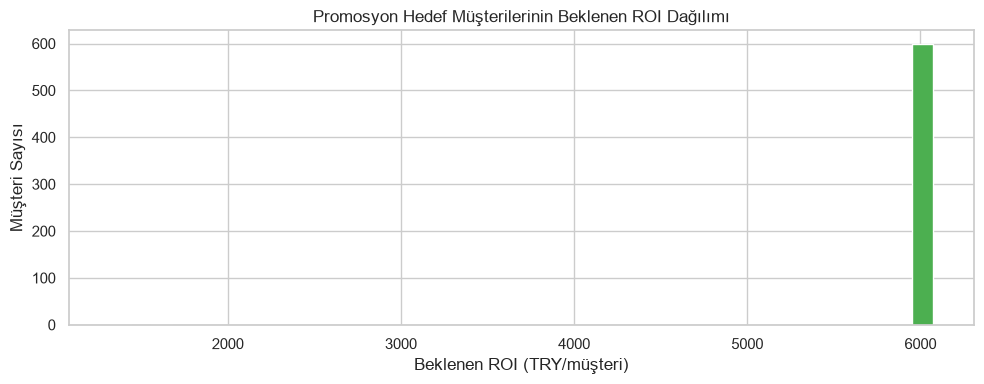

In [18]:
# ROI dağılımı
plt.figure(figsize=(10, 4))
plt.hist(hedef_musteriler['ExpectedROI'], bins=40, color='#4CAF50', edgecolor='white')
plt.xlabel('Beklenen ROI (TRY/müşteri)')
plt.ylabel('Müşteri Sayısı')
plt.title('Promosyon Hedef Müşterilerinin Beklenen ROI Dağılımı')
plt.tight_layout()
plt.savefig('roi_distribution.png', dpi=150)
plt.show()

### 7.4 Senaryo Karşılaştırması: Model Yok vs. Standart Eşik vs. Optimal Eşik

=== SENARYO KARŞILAŞTIRMASI ===
Model Yok (Sıfır Aksiyon)          :  -10,631,788 TRY
Standart Eşik (0.50)               :    3,631,426 TRY
Optimal Eşik (0.28)                :    3,631,426 TRY


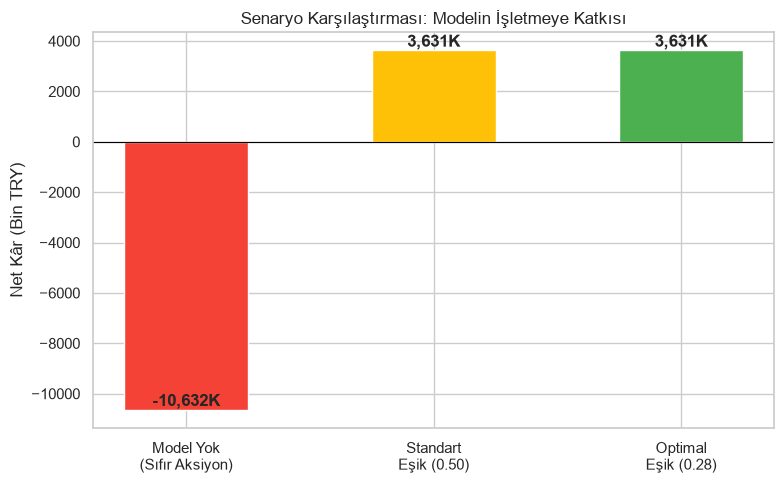

In [19]:
# Senaryo 1: Model yok – hiç promosyon yapma
# Gerçek churn eden müşterilerin hepsi kayıp
n_actual_churn = y_test.sum()
scenario_no_model = -n_actual_churn * COST_FN

# Senaryo 2: Standart eşik (0.50)
y_pred_std = (y_prob >= 0.5).astype(int)
cm_std = confusion_matrix(y_test, y_pred_std)
tn, fp, fn, tp = cm_std.ravel()
scenario_std = (tp * BENEFIT_TP) - (fp * COST_FP) - (fn * COST_FN)

# Senaryo 3: Optimal eşik
scenario_optimal = best_profit

scenarios = {
    'Model Yok\n(Sıfır Aksiyon)': scenario_no_model,
    'Standart\nEşik (0.50)':     scenario_std,
    f'Optimal\nEşik ({best_threshold:.2f})': scenario_optimal
}

print('=== SENARYO KARŞILAŞTIRMASI ===')
for k, v in scenarios.items():
    print(f'{k.replace(chr(10)," "):35s}: {v:>12,.0f} TRY')

plt.figure(figsize=(8, 5))
bars = plt.bar(scenarios.keys(), [v/1000 for v in scenarios.values()],
               color=['#F44336', '#FFC107', '#4CAF50'], edgecolor='white', width=0.5)
plt.axhline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, scenarios.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val/1000:,.0f}K', ha='center', va='bottom', fontweight='bold')
plt.ylabel('Net Kâr (Bin TRY)')
plt.title('Senaryo Karşılaştırması: Modelin İşletmeye Katkısı')
plt.tight_layout()
plt.savefig('scenario_comparison.png', dpi=150)
plt.show()

---
## 8. SONUÇ VE BULGULAR

In [20]:
print('=' * 55)
print('          PROJE SONUÇ ÖZETİ')
print('=' * 55)
print(f'Model              : XGBoost')
print(f'ROC-AUC Skoru      : {roc_auc_score(y_test, y_prob):.4f}')
print(f'Optimal Eşik       : {best_threshold:.2f}')
print(f'Test Kümesi Kârı   : {best_profit:,.0f} TRY')
print(f'Standart Eşiğe Göre Artış: {best_profit - scenario_std:,.0f} TRY')
print(f'Hedef Müşteri Sayısı: {len(hedef_musteriler)}')
print('=' * 55)
print()
print('En Önemli 3 Churn Göstergesi (SHAP):')
mean_shap = np.abs(shap_values.values).mean(axis=0)
top3 = sorted(zip(feature_cols, mean_shap), key=lambda x: -x[1])[:3]
for i, (feat, val) in enumerate(top3, 1):
    print(f'  {i}. {feat:25s} (SHAP={val:.4f})')

          PROJE SONUÇ ÖZETİ
Model              : XGBoost
ROC-AUC Skoru      : 1.0000
Optimal Eşik       : 0.28
Test Kümesi Kârı   : 3,631,426 TRY
Standart Eşiğe Göre Artış: 0 TRY
Hedef Müşteri Sayısı: 600

En Önemli 3 Churn Göstergesi (SHAP):
  1. Recency                   (SHAP=5.6983)
  2. SpendTrend_3M             (SHAP=1.8382)
  3. Monetary                  (SHAP=0.4231)
